In [1]:
!pip install -U langchain langchain_community langchain_google_genai langgraph pypdf

  Obtaining dependency information for langchain from https://files.pythonhosted.org/packages/f3/39/ed3121ea3a0c60a0cda6ea5c4c1cece013e8bbc9b18344ff3ae507728f98/langchain-1.1.3-py3-none-any.whl.metadata
  Obtaining dependency information for langchain_google_genai from https://files.pythonhosted.org/packages/d5/d0/f05cb2ce4ad5b4f4c3addd5978e6b776479db68dcfe55d09e30a8974eda7/langchain_google_genai-4.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for pypdf from https://files.pythonhosted.org/packages/db/ef/68c0f473d8b8764b23f199450dfa035e6f2206e67e9bde5dd695bab9bdf0/pypdf-6.4.1-py3-none-any.whl.metadata
  Obtaining dependency information for langchain-core<2.0.0,>=1.1.2 from https://files.pythonhosted.org/packages/58/41/6db768d4b208a33b4f09d5415e617d489f68167bb5dd27f87c7a49d13caf/langchain_core-1.1.3-py3-none-any.whl.metadata
  Obtaining dependency information for google-genai<2.0.0,>=1.53.0 from https://files.pythonhosted.org/packages/5c/93/7096cdc1a4a55cc60bc02638f707


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


 لطفاً لینک PDF مقاله  را وارد کن.
    - مثال لینک: https://arxiv.org/pdf/2303.04864.pdf

 هیچ ورودی داده نشد، از لینک پیش‌فرض استفاده می‌کنم:
https://arxiv.org/pdf/2303.04864.pdf
 Download Complete.
 Processing PDF content...
 Text processed: 69 chunks ready.
 Processing PDF content...
 Text processed: 69 chunks ready.
 Graph Built Successfully.


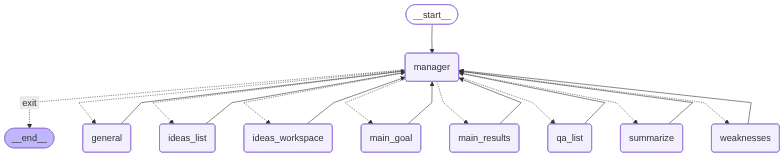


 Welcome to the Intelligent Research Assistant Bot!
I am designed to help you analyze academic papers efficiently with memory and context awareness.

Here is what I can do for you:
   1.  Summarize: Type 'summarize' or 'خلاصه کن'
   2.  Goals: Type 'goal'
   3.  Results: Type 'results'
   4.  Q&A: Type 'qa list'
   5.  Critique: Type 'weaknesses'
   6.  Ideas Workspace & List:
      - «ایده‌های مقاله رو بگو» → ایده‌های به‌کاررفته در خود پژوهش
      - «ایده‌های جدید بده» → ایده‌های پژوهشی جدید
      - «این ایده رو در لیست ذخیره کن» → ذخیره در لیست ایده‌ها
      - «لیست ایده‌ها رو نشان بده» → نمایش ایده‌های ذخیره‌شده
      - «ایده اول را حذف کن» → حذف از لیست
   7.  Contextual Chat: follow-ups like:
      - 'بیشتر توضیح بده'
      - 'ترجمه کن'

[Type 'exit' or 'خروج' to quit the session]
------------------------------------------------------------

 Waiting for input...
 User: لیست ایده ها رو به من نشون بده

 Ideas List: Managing stored ideas...

 IDEAS LIST OUTPUT:
 فعلاً هیچ ایده‌ای د

In [15]:





import os
import requests
from typing import List, TypedDict
from IPython.display import Image, display
import re
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END









os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY", "Add your api-key")

print(" لطفاً لینک PDF مقاله  را وارد کن.")
print("    - مثال لینک: https://arxiv.org/pdf/2303.04864.pdf")

user_pdf_input = input(" ورودی شما (خالی = استفاده از لینک پیش‌فرض): ").strip()


pdf_filename = "paper.pdf"


if user_pdf_input == "":
    pdf_url = "https://arxiv.org/pdf/2303.04864.pdf"
    print(f"\n هیچ ورودی داده نشد، از لینک پیش‌فرض استفاده می‌کنم:\n{pdf_url}")
    try:
        response = requests.get(pdf_url)
        response.raise_for_status()
        with open(pdf_filename, "wb") as f:
            f.write(response.content)
        print(" Download Complete.")
    except Exception as e:
        print(f" Download Error (default URL): {e}")
        pdf_filename = None


elif user_pdf_input.startswith("http://") or user_pdf_input.startswith("https://"):
    pdf_url = user_pdf_input
    print(f"\n Downloading PDF from URL:\n{pdf_url}")
    try:
        response = requests.get(pdf_url)
        response.raise_for_status()
        with open(pdf_filename, "wb") as f:
            f.write(response.content)
        print(" Download Complete.")
    except Exception as e:
        print(f" Download Error: {e}")
        pdf_filename = None


else:
    if os.path.exists(user_pdf_input):
        pdf_filename = user_pdf_input
        print(f"\n Using local PDF file:\n{pdf_filename}")
    else:
        print(f" مسیر فایل پیدا نشد: {user_pdf_input}")
        pdf_filename = None

# ==========================================
# 3. پردازش متن PDF
# ==========================================
if pdf_filename is None:
    print(" Critical Error: هیچ فایل PDF معتبری برای پردازش پیدا نشد.")
else:
    print(" Processing PDF content...")
    try:
        loader = PyPDFLoader(pdf_filename)
        pages = loader.load()
        text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
        all_splits = text_splitter.split_documents(pages)
        print(f" Text processed: {len(all_splits)} chunks ready.")
    except Exception as e:
        print(f" Processing Error: {e}")
        all_splits = []




print(" Processing PDF content...")
try:
    loader = PyPDFLoader(pdf_filename)
    pages = loader.load()
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    all_splits = text_splitter.split_documents(pages)
    print(f" Text processed: {len(all_splits)} chunks ready.")
except Exception as e:
    print(f" Processing Error: {e}")
    all_splits = []

# ==========================================
# 4. State تعریف
# ==========================================
class AgentState(TypedDict):
    documents: List[Document]
    user_request: str

    # تاریخچه‌ی هر نود اصلی
    summary_history: List[str]
    goal_history: List[str]
    results_history: List[str]
    qa_history: List[str]
    weaknesses_history: List[str]
    ideas_history: List[str]
    general_history: List[str]

    # آخرین خروجی هر نود
    summary_last_output: str
    goal_last_output: str
    results_last_output: str
    qa_last_output: str
    weaknesses_last_output: str
    general_last_output: str


    ideas_last_output: str             
    ideas_recent_candidates: List[str]  
    ideas_memory: List[str]             


    last_active_agent: str


    final_response: str

# ==========================================
# 5. مدل و روتر
# ==========================================
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    temperature=0,
    max_output_tokens=1024,
)

ROUTER_PROMPT = """You are the Router. Analyze the user request.
Respond with ONE keyword ONLY:
- 'summarize'       : summary of the paper
- 'main_goal'       : goals/objectives
- 'main_results'    : results/findings
- 'qa_list'         : questions & answers
- 'weaknesses'      : critiques/limitations of the paper
- 'ideas_workspace' : general idea processing (creating, critiquing, improving ideas)
- 'ideas_list'      : managing the ideas memory/list (show, add, delete, discuss saved ideas)
- 'exit'            : if user wants to quit
- 'general'         : everything else (chat, explain more, translate, etc.)

User Request: {user_request}
"""

def get_router_decision(state: AgentState) -> str:
    user_request = state["user_request"]
    ur = user_request.lower()


    if ("ایده" in user_request) or ("idea" in ur) or ("ideas" in ur) or ("brainstorm" in ur):


        if (
            ("لیست ایده" in user_request or "لیست ایده‌ها" in user_request or "لیست ایده ها" in user_request or "از لیست" in user_request)
            and (
                "نقد" in user_request
                or "بیشتر توضیح" in user_request
                or "بیشتر توضیح بده" in user_request
                or "توضیح بده" in user_request
                or "گسترش" in user_request
                or "توسعه" in user_request
                or "بهبود" in user_request
                or "ترکیب" in user_request
                or "combine" in ur
            )
        ):
            return "ideas_workspace"


        if (
            "لیست ایده" in user_request
            or "فهرست ایده" in user_request
            or "ایده‌های ذخیره شده" in user_request
            or "ایده های ذخیره شده" in user_request
            or "ایده‌های تایید شده" in user_request
            or "ایده های تایید شده" in user_request
            or "ایده‌های مورد تایید" in user_request
            or "ایده های مورد تایید" in user_request
            or "approved ideas" in ur
            or "saved ideas" in ur
            or ("به لیست" in user_request)
            or ("در لیست" in user_request)
            or (("ذخیره" in user_request or "تایید" in user_request or "تایيد" in user_request) and "ایده" in user_request)
            or (("حذف" in user_request or "پاک کن" in user_request or "پاکش کن" in user_request) and "ایده" in user_request)
        ):
            return "ideas_list"


        return "ideas_workspace"

    # --- بقیه‌ی مسیرها با LLM ---
    prompt = ROUTER_PROMPT.format(user_request=user_request)
    response = model.invoke([HumanMessage(content=prompt)])
    decision = (response.content or "").strip().lower()

    valid = [
        "summarize",
        "main_goal",
        "main_results",
        "qa_list",
        "weaknesses",
        "ideas_workspace",
        "ideas_list",
        "exit",
        "general",
    ]
    if decision not in valid:
        for v in valid:
            if v in decision:
                return v
        return "general"
    return decision


# ==========================================
# 6. توابع کمکی
# ==========================================
def filter_docs_by_keywords(docs: List[Document], keywords: List[str], max_chars: int = 12000) -> str:
    """
    فقط صفحاتی را که شامل یکی از کلیدواژه‌ها هستند انتخاب می‌کند.
    اگر هیچ صفحه‌ای match نشد، کل داکیومنت را برمی‌گرداند.
    """
    selected = []
    for d in docs:
        lower = d.page_content.lower()
        if any(k.lower() in lower for k in keywords):
            selected.append(d.page_content)

    if not selected:

        selected = [d.page_content for d in docs]

    text = "\n\n".join(selected)
    return text[:max_chars]


def get_results_text(docs: List[Document]) -> str:

    keywords = [
        "results", "result", "evaluation", "experiment", "experiments",
        "performance", "table", "figure", "accuracy", "precision", "recall",
        "f1", "baseline", "comparison"
    ]
    return filter_docs_by_keywords(docs, keywords, max_chars=16000)


def get_questions_text(docs: List[Document]) -> str:

    keywords = [
        "research question", "research questions", "rq1", "rq2", "rq3",
        "we ask", "we investigate", "we study whether",
        "our questions", "we aim to answer",
        "question we address",
        "پرسش اصلی", "پرسش‌های اصلی", "سوال پژوهش", "سوالات پژوهش",
        "سؤالات پژوهش", "پرسش‌های تحقیق", "سوالات تحقیق"
    ]
    return filter_docs_by_keywords(docs, keywords, max_chars=12000)


def format_docs(docs: List[Document]) -> str:
    return "\n\n".join([d.page_content for d in docs])

def format_history(history: List[str]) -> str:
    if not history:
        return "No previous exchanges."
    return "\n\n".join(history[-6:])

def extract_bullet_ideas(text: str) -> List[str]:
    """خط‌هایی که با * یا - شروع شده‌اند را به عنوان ایده جدا می‌کند."""
    ideas = []
    for line in text.splitlines():
        line = line.strip()
        if line.startswith("*") or line.startswith("-"):
            ideas.append(line.lstrip("*- ").strip())
    return ideas

def format_ideas_list(ideas: List[str]) -> str:
    if not ideas:
        return " فعلاً هیچ ایده‌ای در لیست موجود نیست."
    lines = [" لیست ایده‌ها:"]
    for i, idea in enumerate(ideas, start=1):
        lines.append(f"{i}. {idea}")
    return "\n".join(lines)

def pick_indices_from_text(text: str, max_len: int) -> List[int]:
    """
    شماره ایده‌ها را از متن کاربر استخراج می‌کند.
    پشتیبانی می‌کند از:
    - «ایده ۳»، «ایده شماره 5»
    - «ایده‌های 3 تا 5»
    - «3 تا 5»
    - «10 تا اول ایده‌ها» (یعنی ایده‌های 1 تا 10)
    - «ایده اول، دوم، سوم» (با کلمات)
    """

    import re

    indices = set()


    persian_digits = "۰۱۲۳۴۵۶۷۸۹"
    english_digits = "0123456789"
    trans_table = str.maketrans("".join(persian_digits), "".join(english_digits))
    norm_text = text.translate(trans_table)


    for m in re.findall(r'(\d+)\s*تا\s*(\d+)', norm_text):
        start = int(m[0])
        end = int(m[1])
        if start > end:
            start, end = end, start
        for n in range(start, end + 1):
            if 1 <= n <= max_len:
                indices.add(n - 1)


    m1 = re.search(r'\b(\d+)\s*تا\s*اول', norm_text)
    if m1:
        end = int(m1.group(1))
        for n in range(1, min(end, max_len) + 1):
            indices.add(n - 1)

    m2 = re.search(r'اول\s*تا\s*(\d+)', norm_text)
    if m2:
        end = int(m2.group(1))
        for n in range(1, min(end, max_len) + 1):
            indices.add(n - 1)



    for m in re.findall(r'\b(\d+)\b', norm_text):
        n = int(m)
        if 1 <= n <= max_len:
            indices.add(n - 1)


    mapping_words = {
        "اول": 0,
        "نخست": 0,
        "دوم": 1,
        "سوم": 2,
        "چهارم": 3,
        "پنجم": 4,
    }
    for w, idx in mapping_words.items():
        if w in text and idx < max_len:
            indices.add(idx)


    if ("آخر" in text or "آخرین" in text) and max_len > 0:
        indices.add(max_len - 1)

    return sorted(indices)


# ==========================================
# 7. نودها (summary / goal / results / qa / weaknesses / ideas / general)
# ==========================================

# --- 1. Summarizer ---
def summarize_node(state: AgentState):
    print("\n Manager: Delegated to Summarizer...")
    docs_text = format_docs(state["documents"])
    node_history = state.get("summary_history", [])
    last_output = state.get("summary_last_output", "")

    prompt = f"""You are the Summarizer agent.

--- YOUR PAST EXCHANGES ---
{format_history(node_history)}

--- YOUR LATEST SUMMARY (IF ANY) ---
{last_output if last_output else "No summary has been generated yet."}

--- CURRENT USER REQUEST ---
{state['user_request']}

INSTRUCTIONS:
1. If the user (in Persian or English) is asking to EXPLAIN / TRANSLATE / EXPAND
   "the summary", "خلاصه", "it", "آن", then:
   - Base your answer ONLY on YOUR LATEST SUMMARY above.
   - Do NOT generate a new summary of the whole paper.
2. Otherwise, create a NEW detailed summary of the full paper (4+ paragraphs).

--- PAPER CONTENT (TRUNCATED) ---
{docs_text[:10000]}...
"""
    response = model.invoke([HumanMessage(content=prompt)])
    print(f"\n SUMMARY RESULT:\n{response.content}\n")

    new_entry = f"User: {state['user_request']}\nAI (Summary): {response.content}"
    new_hist = node_history + [new_entry]

    return {
        "summary_history": new_hist,
        "summary_last_output": response.content,
        "last_active_agent": "summarize",
        "final_response": response.content,
    }

# --- 2. Goal Extractor ---
def main_goal_node(state: AgentState):
    print("\n Manager: Delegated to Goal Extractor...")
    docs_text = format_docs(state["documents"])
    node_history = state.get("goal_history", [])
    last_output = state.get("goal_last_output", "")

    prompt = f"""You are the Goal Extractor agent.

--- YOUR PAST EXCHANGES ---
{format_history(node_history)}

--- YOUR LATEST OUTPUT (IF ANY) ---
{last_output if last_output else "No goals extracted yet."}

--- CURRENT USER REQUEST ---
{state['user_request']}

INSTRUCTIONS:
1. If the user asks to EXPLAIN / TRANSLATE / EXPAND "the goal(s)", "هدف", etc.,
   use YOUR LATEST OUTPUT above as the base.
2. Otherwise, extract and explain the MAIN GOALS of the paper in a few paragraphs.

--- PAPER CONTENT (TRUNCATED) ---
{docs_text[:6000]}
"""
    response = model.invoke([HumanMessage(content=prompt)])
    print(f"\n GOAL RESULT:\n{response.content}\n")

    new_entry = f"User: {state['user_request']}\nAI (Goal): {response.content}"
    new_hist = node_history + [new_entry]

    return {
        "goal_history": new_hist,
        "goal_last_output": response.content,
        "last_active_agent": "main_goal",
        "final_response": response.content,
    }

# --- 3. Results Extractor ---
def main_results_node(state: AgentState):
    print("\n Manager: Delegated to Result Extractor (EXPERIMENTAL RESULTS)...")


    docs_text = get_results_text(state["documents"])
    node_history = state.get("results_history", [])
    last_output = state.get("results_last_output", "")

    prompt = f"""You are the Results Extractor agent.

Your job is to read ONLY the PAPER TEXT below and extract the **experimental / evaluation results**.

VERY IMPORTANT RULES:
- Use only information that is explicitly present in the paper text.
- Do NOT invent datasets, baselines, metrics, or numbers.
- If a specific detail is not in the text, say clearly: «اطلاعات کافی در متن موجود نبود».
- Focus on tables, figures, and the "Results / Evaluation / Experiments" sections.

--- YOUR PAST EXCHANGES ---
{format_history(node_history)}

--- YOUR LATEST OUTPUT (IF ANY) ---
{last_output if last_output else "No results extracted yet."}

--- CURRENT USER REQUEST ---
{state['user_request']}

INSTRUCTIONS:

1. First, identify the main experiments / evaluation questions. For each one, try to extract:
   - Task / dataset
   - Compared methods (especially proposed method vs baselines)
   - Metrics (e.g., accuracy, F1, etc.)
   - If numbers exist (e.g., 0.85 vs 0.78), copy them exactly from the text.
   - Whether the proposed method is better/worse/similar, based on the paper.

2. Answer in Persian with this structure:

- **نتیجه ۱ – [عنوان کوتاه برای این آزمایش]**
  - وظیفه / دیتاست: ...
  - روش‌ها / بیس‌لاین‌ها: ...
  - متریک‌ها و اعداد: ...
  - جمع‌بندی: ...

- **نتیجه ۲ – ...**
  ...

3. اگر در متن، بخش مشخصی با اعداد و مقایسه‌ها پیدا نکردی، صادقانه بنویس:
   «در متن موجود، بخش نتایج عددی و مقایسه با بیس‌لاین‌ها به‌طور واضح یافت نشد. در نتیجه فقط می‌توانم نتایج کیفی/کلی را بیان کنم.»
   و بعد، اگر ممکن بود، فقط یک خلاصه‌ی کیفی کوتاه بده.

--- PAPER RESULTS/EVALUATION CONTENT (TRUNCATED) ---
{docs_text}
"""
    response = model.invoke([HumanMessage(content=prompt)])
    print(f"\n RESULTS (EXPERIMENTAL):\n{response.content}\n")

    new_entry = f"User: {state['user_request']}\nAI (Results): {response.content}"
    new_hist = node_history + [new_entry]

    return {
        "results_history": new_hist,
        "results_last_output": response.content,
        "last_active_agent": "main_results",
        "final_response": response.content,
    }


# --- 4. Q&A Generator ---
def qa_list_node(state: AgentState):
    print("\n Manager: Delegated to Q&A (RESEARCH QUESTIONS)...")

    docs_text = get_questions_text(state["documents"])
    node_history = state.get("qa_history", [])
    last_output = state.get("qa_last_output", "")

    prompt = f"""You are the Q&A agent, but your specific job is:

 Extract the **research questions of the paper itself** (if any), and for each one, summarize the answer the paper gives.

VERY IMPORTANT RULES:
- Use ONLY the paper text below.
- Do NOT invent research questions as if they were explicitly stated by the authors.
- If the paper has explicit "Research Questions", "RQ1", "RQ2", etc., use exactly those.
- If there are no explicit questions, you MUST:
  (a) clearly say that no explicit RQs were found, and
  (b) then create 2–3 *inferred* research questions based on the goals and contributions,
      and provide answers for them, clearly marked as inferred.

--- YOUR PAST EXCHANGES ---
{format_history(node_history)}

--- YOUR LATEST Q&A OUTPUT (IF ANY) ---
{last_output if last_output else "No Q&A extracted yet."}

--- CURRENT USER REQUEST ---
{state['user_request']}

INSTRUCTIONS (OUTPUT FORMAT IN PERSIAN):

1. If you find explicit research questions (e.g., “Research Question”, “RQ1”, “RQ2”, ...), use this format:

- **پرسش ۱ (RQ1 – متن خود مقاله اگر ممکن است):**
  - متن پرسش: ...
  - پاسخ مقاله: ۲–۴ جمله بر اساس نتایج/بحث که توضیح می‌دهد مقاله چه جوابی به این پرسش داده است.

- **پرسش ۲ (RQ2 – ...):**
  - متن پرسش: ...
  - پاسخ مقاله: ...

2. اگر هیچ پرسش پژوهشی صریح پیدا نکردی، خروجی حتماً باید این دو بخش را داشته باشد:

   **بخش اول – اعلام عدم وجود RQ صریح:**
   - یک جمله شبیه این بنویس:
     «در متن موجود، پرسش‌های پژوهشی صریح (مثل RQ1، RQ2) یافت نشد.»

   **بخش دوم – پرسش‌های استنباط‌شده از اهداف مقاله:**
   - حداقل ۲ و حداکثر ۳ پرسش تولید کن با این ساختار:

   - **پرسش استنباط‌شده ۱: [پرسشی که از اهداف/مسأله اصلی مقاله برداشت می‌شود]**
     - پاسخ استنباط‌شده مقاله: ۲–۴ جمله که بر اساس اهداف، روش و نتایج توضیح می‌دهد مقاله عملاً چه پاسخی داده است.

   - **پرسش استنباط‌شده ۲: ...**
     - پاسخ استنباط‌شده مقاله: ...

   اگر اطلاعات برای پاسخ دقیق کافی نیست، این را هم در متن پاسخ بنویس.

3. هر جا مطمئن نیستی، صادقانه بگو از روی متن دقیق پیدا نکردم، ولی بر اساس کلیت مقاله حدس زده شده است.

--- PAPER TEXT (FOCUSED ON RESEARCH QUESTIONS, TRUNCATED) ---
{docs_text}
"""
    response = model.invoke([HumanMessage(content=prompt)])
    print(f"\n RESEARCH Q&A:\n{response.content}\n")

    new_entry = f"User: {state['user_request']}\nAI (Q&A): {response.content}"
    new_hist = node_history + [new_entry]

    return {
        "qa_history": new_hist,
        "qa_last_output": response.content,
        "last_active_agent": "qa_list",
        "final_response": response.content,
    }


# --- 5. Critic / Weaknesses ---
def weaknesses_node(state: AgentState):
    print("\n Manager: Delegated to Critic...")
    docs_text = format_docs(state["documents"])
    node_history = state.get("weaknesses_history", [])
    last_output = state.get("weaknesses_last_output", "")

    prompt = f"""You are the Critic agent (for the PAPER, not for user ideas).

--- YOUR PAST EXCHANGES ---
{format_history(node_history)}

--- YOUR LATEST OUTPUT (IF ANY) ---
{last_output if last_output else "No weaknesses listed yet."}

--- CURRENT USER REQUEST ---
{state['user_request']}

INSTRUCTIONS:
1. If the user explicitly asks for explanation/translation of the weaknesses,
   use YOUR LATEST OUTPUT above.
2. Otherwise, identify main weaknesses / limitations of THE PAPER:
   - methodological, data, evaluation, ethical, etc.

--- PAPER CONTENT (TRUNCATED) ---
{docs_text[:6000]}
"""
    response = model.invoke([HumanMessage(content=prompt)])
    print(f"\n WEAKNESSES:\n{response.content}\n")

    new_entry = f"User: {state['user_request']}\nAI (Weaknesses): {response.content}"
    new_hist = node_history + [new_entry]

    return {
        "weaknesses_history": new_hist,
        "weaknesses_last_output": response.content,
        "last_active_agent": "weaknesses",
        "final_response": response.content,
    }

# ==========================================
# 7-a. نود فضای پردازش ایده‌ها
# ==========================================
def ideas_workspace_node(state: AgentState):
    print("\n Ideas Workspace: Processing ideas...")

    user_req = state["user_request"].strip()
    ur = user_req.lower()

    docs_text = format_docs(state["documents"])
    ideas_history = state.get("ideas_history", [])
    last_output = state.get("ideas_last_output", "")
    recent_candidates = state.get("ideas_recent_candidates", [])
    ideas_memory = state.get("ideas_memory", [])

    out = ""
    new_candidates: List[str] = []








    use_list_idea = False
    selected_idea_text = ""

    if ideas_memory and (
        "از لیست ایده" in user_req
        or "از لیست ایده‌ها" in user_req
        or "از لیست ایده ها" in user_req
        or ("لیست ایده" in user_req and "از لیست" in user_req)
    ):
        idxs = pick_indices_from_text(user_req, len(ideas_memory))
        if idxs:
            use_list_idea = True
            selected_idea_text = ideas_memory[idxs[0]]  # فعلاً فقط اولین اندیس

    if use_list_idea:
        prompt = f"""کاربر می‌خواهد روی یک ایده از "لیست ایده‌ها" کار کند.

ایده‌ی انتخاب‌شده از لیست:
{selected_idea_text}

درخواست کاربر:
{user_req}

دستورالعمل:

- اگر کاربر گفته «نقد کن» یا چیزی شبیه آن:
  - ایده را از نظر نوآوری، امکان‌پذیری، منابع مورد نیاز، ریسک‌ها و چالش‌ها نقد کن.
  - نقاط قوت و ضعف را جداگانه فهرست کن.
- اگر کاربر گفته «بیشتر توضیح بده / توسعه بده / گسترش بده»:
  - ایده را به یک طرح پژوهشی کامل‌تر تبدیل کن:
    - مسئله و هدف دقیق،
    - روش پیشنهادی (متدولوژی)،
    - نوع داده و جمع‌آوری آن،
    - نحوه‌ی ارزیابی و سنجش موفقیت.
- اگر کاربر گفته «ترکیب با X» (مثلاً «با رجکس ترکیب کن»):
  - یک ایده‌ی پژوهشی جدید که ترکیب این ایده با X است تعریف کن،
  - توضیح بده دقیقاً چه چیزی ترکیب می‌شود و چه خروجی جدیدی به‌دست می‌آید.

خروجی را به فارسی و تا حد امکان ساختارمند بنویس:
- با تیترهای کوتاه،
- بولت‌پوینت‌ها،
- و در پایان، یک نسخه‌ی یک‌جمله‌ایِ خلاصه از ایده‌ی (نقدشده/توسعه‌یافته/ترکیبی) بده
  که بعداً بتوان آن را به‌عنوان یک "ایده‌ی نهایی" در لیست ذخیره کرد.
"""
        response = model.invoke([HumanMessage(content=prompt)])
        out = response.content
        new_candidates = extract_bullet_ideas(response.content)

        print(f"\n IDEAS WORKSPACE OUTPUT (from list idea):\n{out}\n")

        new_entry = f"User: {user_req}\nAI (Ideas-From-List): {out}"
        new_hist = ideas_history + [new_entry]

        return {
            "ideas_history": new_hist,
            "ideas_last_output": out,
            "ideas_recent_candidates": new_candidates,
            "ideas_memory": ideas_memory,  # هنوز خود لیست را عوض نمی‌کنیم
            "last_active_agent": "ideas_workspace",
            "final_response": out,
        }

    # ==========================================
    # 1) ایده‌های به‌کاررفته در خود پژوهش
    # ==========================================
    ask_used_in_paper = (
        "ایده‌های به کار رفته" in user_req
        or "ایده های به کار رفته" in user_req
        or "ایده‌های بکار رفته" in user_req
        or "ایده های بکار رفته" in user_req
        or ("ایده" in user_req and "مقاله" in user_req and "خود پژوهش" in user_req)
        or ("ایده" in user_req and "مقاله" in user_req and "کار پژوهشی" in user_req)
        or ("ایده های مقاله" in user_req)
        or ("ایده‌های مقاله" in user_req)
        or ("ایده های مقاله رو بگو" in user_req)
    )

    if ask_used_in_paper:
        prompt = f"""You are an agent that extracts the main ideas/methods that THIS PAPER itself
actually used to conduct its research (not future work).

Examples: مدل/فریم‌ورک پیشنهادی، شاخص جدید، روش آزمایش، معماری، نوع داده، طراحی مطالعه موردی.

Answer in Persian.
Use bullet points; هر بولت = یک ایده + ۱–۲ جمله توضیح.

--- PAPER CONTENT (TRUNCATED) ---
{docs_text[:8000]}
"""
        response = model.invoke([HumanMessage(content=prompt)])
        out = " ایده‌ها و روش‌های به‌کاررفته در خود پژوهش:\n\n" + response.content
        new_candidates = extract_bullet_ideas(response.content)

    # ==========================================
    # 2) ایده‌های جدید از طرف ایجنت (brainstorm)
    # ==========================================
    elif ("ایده" in user_req and "جدید" in user_req) or "ایده بده" in user_req or "new ideas" in ur or "brainstorm" in ur:
        prompt = f"""You are a research-ideas generator.

The user wants NEW research ideas related to this paper.

Answer in Persian.
Use bullet points; هر بولت = عنوان کوتاه + ۲–۳ جمله توضیح.

--- PAPER CONTENT (TRUNCATED) ---
{docs_text[:8000]}
"""
        response = model.invoke([HumanMessage(content=prompt)])
        out = " ایده‌های پژوهشی جدید پیشنهادی:\n\n" + response.content
        new_candidates = extract_bullet_ideas(response.content)

    # ==========================================
    # 3) نظر/نقد/بهبود روی ایده‌ای که کاربر خودش مطرح می‌کند (متن آزاد)
    # ==========================================
    elif (
        ("نظرت" in user_req and "ایده" in user_req)
        or ("نظر" in user_req and "ایده" in user_req)
        or ("این ایده رو نقد" in user_req)
        or ("این ایده را نقد" in user_req)
        or ("ایده من" in user_req)
        or ("ایده خودم" in user_req)
        or ("این ایده رو بهترش کن" in user_req)
        or ("بهبود" in user_req and "ایده" in user_req)
    ):
        prompt = f"""کاربر درباره یک یا چند ایده برای پژوهش صحبت کرده و می‌خواهد نظر/نقد/بهبود تو را بداند.

ایده‌ها و توضیحات کاربر:

{user_req}

لطفاً:
- ایده(ها) را خلاصه کن،
- نقاط قوت و ضعف را بگو،
- پیشنهادهایی برای بهبود/واضح‌تر شدن/قابل‌اجرا شدن ارائه کن.

پاسخ را به فارسی و تا حد امکان ساختارمند (بولت‌پوینت) بده.
"""
        response = model.invoke([HumanMessage(content=prompt)])
        out = " نقد و بهبود روی ایده‌ی شما:\n\n" + response.content
        new_candidates = extract_bullet_ideas(response.content)

    # ==========================================
    # 4) فالوآپ روی خروجی قبلی ایده‌ها
    # ==========================================
    elif last_output:
        prompt = f"""You are continuing an ideas-related conversation.

--- LAST IDEAS OUTPUT ---
{last_output}

--- USER REQUEST ---
{user_req}

IF the user is asking to explain/clarify/critique/improve specific idea(s) from above:
- focus on those idea(s).
- use Persian.
- پاسخ را ساختارمند و با بولت‌پوینت بده.
"""
        response = model.invoke([HumanMessage(content=prompt)])
        out = response.content
        new_candidates = extract_bullet_ideas(response.content)

    # ==========================================
    # 5) حالت پیش‌فرض
    # ==========================================
    else:
        prompt = f"""You are an ideas assistant.

The user is asking something about ideas, but it's not very specific.

Try to:
- understand what they want about research ideas around this paper,
- answer in Persian,
- if appropriate, suggest 2–5 concrete research ideas as bullet points.

--- USER REQUEST ---
{user_req}

--- PAPER CONTENT (TRUNCATED) ---
{docs_text[:6000]}
"""
        response = model.invoke([HumanMessage(content=prompt)])
        out = response.content
        new_candidates = extract_bullet_ideas(response.content)

    print(f"\n IDEAS WORKSPACE OUTPUT:\n{out}\n")

    new_entry = f"User: {user_req}\nAI (Ideas-Workspace): {out}"
    new_hist = ideas_history + [new_entry]

    return {
        "ideas_history": new_hist,
        "ideas_last_output": out,
        "ideas_recent_candidates": new_candidates,
        "ideas_memory": ideas_memory,
        "last_active_agent": "ideas_workspace",
        "final_response": out,
    }


# ==========================================
# 7-b. نود مدیریت لیست ایده‌ها
# ==========================================
def ideas_list_node(state: AgentState):
    print("\n Ideas List: Managing stored ideas...")

    user_req = state["user_request"]
    ur = user_req.lower()

    # تاریخچه و وضعیت فعلی
    ideas_history = state.get("ideas_history", [])
    recent_candidates = state.get("ideas_recent_candidates", [])
    ideas_memory = state.get("ideas_memory", [])
    last_ideas_output = state.get("ideas_last_output", "")
    last_agent = state.get("last_active_agent", "")

    # خروجی‌های آخر بقیه نودها برای استفاده به عنوان کانتکست
    summary_last_output = state.get("summary_last_output", "")
    goal_last_output = state.get("goal_last_output", "")
    results_last_output = state.get("results_last_output", "")
    qa_last_output = state.get("qa_last_output", "")
    weaknesses_last_output = state.get("weaknesses_last_output", "")
    general_last_output = state.get("general_last_output", "")

    # تشخیص نیت کاربر
    wants_show = (
        "لیست ایده ها" in user_req
        or "لیست ایده‌ها" in user_req
        or "ایده ها رو نشان بده" in user_req
        or "ایده‌ها رو نشان بده" in user_req
        or "ideas list" in ur
        or ("لیست" in user_req and "ایده" in user_req)
    )

    wants_add = (
        "اضافه کن" in user_req
        or "ذخیره کن" in user_req
        or "در لیست ایده ها" in user_req
        or "در لیست ایده‌ها" in user_req
        or "به لیست ایده ها اضافه کن" in user_req
        or "به لیست ایده‌ها اضافه کن" in user_req
        or "اضافه به لیست" in user_req
        or "add to list" in ur
        or "save idea" in ur
    )

    wants_delete = (
        "حذف" in user_req
        or "پاک کن" in user_req
        or "پاکش کن" in user_req
        or "delete" in ur
        or "remove" in ur
    )


    def _return(out: str, tag: str):
        new_entry = f"User: {user_req}\nAI ({tag}): {out}"
        new_hist = ideas_history + [new_entry]
        return {
            "ideas_history": new_hist,
            "ideas_last_output": out,
            "ideas_recent_candidates": recent_candidates,
            "ideas_memory": ideas_memory,
            "last_active_agent": "ideas_list",
            "final_response": out,
        }


    if wants_show and not wants_add and not wants_delete:
        out = format_ideas_list(ideas_memory)
        print(f"\n IDEAS LIST OUTPUT:\n{out}\n")
        return _return(out, "Ideas-List-Show")

    # --- توابع کمکی ---


    def add_plain_idea(idea_text: str):
        nonlocal ideas_memory
        idea_text = idea_text.strip()
        if not idea_text:
            return " متن ایده خالی است؛ چیزی برای اضافه‌کردن پیدا نکردم."
        if idea_text not in ideas_memory:
            ideas_memory.append(idea_text)
            out_local = " این ایده به لیست ایده‌ها اضافه شد:\n- " + idea_text
        else:
            out_local = " این ایده قبلاً در لیست بود."
        out_local += "\n\n" + format_ideas_list(ideas_memory)
        return out_local


    def get_context_text():
        if last_agent == "summarize" and summary_last_output:
            return summary_last_output
        if last_agent == "main_goal" and goal_last_output:
            return goal_last_output
        if last_agent == "main_results" and results_last_output:
            return results_last_output
        if last_agent == "qa_list" and qa_last_output:
            return qa_last_output
        if last_agent == "weaknesses" and weaknesses_last_output:
            return weaknesses_last_output
        if last_agent in ("ideas_workspace", "ideas_list") and last_ideas_output:
            return last_ideas_output
        if general_last_output:
            return general_last_output
        return last_ideas_output or ""


    def add_from_context():
        base_text = get_context_text()
        if not base_text:
            return (
                " در حال حاضر متنی ندارم که از روی آن ایده بسازم. "
                "اول یک خروجی (مثلاً خلاصه یا ایده‌ی جدید) تولید کن، بعد بگو آن را در لیست ذخیره کنم."
            )
        prompt = f"""در متن زیر، ایده‌ی پژوهشی نهایی/اصلی را که کاربر روی آن تمرکز دارد
در یک جمله‌ی کوتاه و شفاف استخراج کن. فقط همان جمله را بنویس، بدون مقدمه و توضیح اضافه.

متن:
{base_text}
"""
        response = model.invoke([HumanMessage(content=prompt)])
        extracted_idea = (response.content or "").strip()
        if extracted_idea:
            return add_plain_idea(extracted_idea)
        else:
            return (
                " نتوانستم ایده‌ی مشخصی را از گفت‌وگوی قبلی استخراج کنم. "
                "لطفاً ایده را به‌صورت یک جمله‌ی واضح بنویس و بعد بگو آن را در لیست ذخیره کن."
            )


    if wants_add:
        import re as _re



        m = _re.search(r":\s*(.+)$", user_req)
        if m:
            manual_idea = m.group(1).strip()
            if manual_idea:
                out = add_plain_idea(manual_idea)
                print(f"\n IDEAS ADDED OUTPUT (from manual text):\n{out}\n")
                return _return(out, "Ideas-List-Add-Manual")


        wants_single_from_context = (
            "در یک بولت" in user_req
            or "در يك بولت" in user_req
            or "یک بولت" in user_req
            or "يك بولت" in user_req
            or "در یک خط" in user_req
            or "در يك خط" in user_req
            or "یک خط" in user_req
            or "يك خط" in user_req
            or "یک جمله" in user_req
            or "يك جمله" in user_req
            or "در یک جمله" in user_req
            or "در يك جمله" in user_req
            or "همین رو" in user_req
            or "همين رو" in user_req
            or "همین ایده" in user_req
            or "همين ایده" in user_req
        )


        if wants_single_from_context or not recent_candidates:
            out = add_from_context()
            print(f"\n IDEAS ADDED OUTPUT (from context one-line):\n{out}\n")
            return _return(out, "Ideas-List-Add-Context")


        idxs = pick_indices_from_text(user_req, len(recent_candidates))


        if (
            not idxs
            and (
                "ایده ها" in user_req
                or "ایده‌ها" in user_req
                or "این ایده ها" in user_req
                or "این ایده‌ها" in user_req
                or "همه ایده ها" in user_req
                or "همه‌ی ایده ها" in user_req
                or "همه ی ایده ها" in user_req
            )
        ):
            idxs = list(range(len(recent_candidates)))

        if not idxs:
            out = (
                "لطفاً بگو کدام ایده از لیست فعلی را می‌خواهی ذخیره کنی "
                "(مثلاً: «ایده‌ی دوم را در لیست ذخیره کن»)."
            )
            return _return(out, "Ideas-List-Add-AskIndex")

        added = []
        for i in idxs:
            idea = recent_candidates[i]
            if idea not in ideas_memory:
                ideas_memory.append(idea)
                added.append(idea)

        if added:
            out = " ایده(های) زیر به لیست ایده‌ها اضافه شدند:\n"
            for idea in added:
                out += f"- {idea}\n"
        else:
            out = " این ایده(ها) قبلاً در لیست بودند."

        out += "\n\n" + format_ideas_list(ideas_memory)
        print(f"\n IDEAS ADDED OUTPUT (from candidates):\n{out}\n")
        return _return(out, "Ideas-List-Add")

    #  حذف از لیست
    if wants_delete:
        if not ideas_memory:
            out = " فعلاً هیچ ایده‌ای در لیست وجود ندارد که بتوانم حذف کنم."
            return _return(out, "Ideas-List-Delete-Empty")

        idxs = pick_indices_from_text(user_req, len(ideas_memory))


        if not idxs and (
            "این ایده ها" in user_req
            or "این ایده‌ها" in user_req
            or "همه ایده ها" in user_req
            or "همه‌ی ایده ها" in user_req
            or "همه ی ایده ها" in user_req
        ):
            idxs = list(range(len(ideas_memory)))

        if not idxs:
            out = "لطفاً بگو کدام شماره ایده را می‌خواهی حذف کنی (مثلاً: «ایده‌ی اول و سوم را حذف کن»)."
            return _return(out, "Ideas-List-Delete-AskIndex")

        idxs_set = set(idxs)
        deleted = [idea for i, idea in enumerate(ideas_memory) if i in idxs_set]
        ideas_memory[:] = [idea for i, idea in enumerate(ideas_memory) if i not in idxs_set]

        if deleted:
            out = " ایده(های) زیر از لیست حذف شدند:\n"
            for idea in deleted:
                out += f"- {idea}\n"
        else:
            out = " هیچ ایده‌ای حذف نشد."

        out += "\n\n" + format_ideas_list(ideas_memory)
        print(f"\n IDEAS DELETED OUTPUT:\n{out}\n")
        return _return(out, "Ideas-List-Delete")


    out = (
        "برای کار با لیست ایده‌ها می‌توانی بگویی:\n"
        "- «لیست ایده ها را نشان بده»\n"
        "- «این ایده را در لیست ایده‌ها ذخیره کن» یا «همین رو در یک خط در لیست ایده‌ها ذخیره کن»\n"
        "- «ایده‌ی اول و دوم را حذف کن» یا «ایده‌های 1 تا 3 را حذف کن»\n"
        "- «این ایده ها را حذف کن» (برای حذف همه‌ی ایده‌های فعلی)."
    )
    return _return(out, "Ideas-List-Help")



# --- 8. General Chat ---
def general_node(state: AgentState):
    print("\n Manager: Delegated to General Chat (Context Aware)...")

    user_req = state["user_request"]
    user_req_low = user_req.lower()
    docs_text = format_docs(state["documents"])

    general_history = state.get("general_history", [])
    general_last_output = state.get("general_last_output", "")
    last_agent = state.get("last_active_agent", "")

    summary_last = state.get("summary_last_output", "")
    goal_last = state.get("goal_last_output", "")
    results_last = state.get("results_last_output", "")
    qa_last = state.get("qa_last_output", "")
    weaknesses_last = state.get("weaknesses_last_output", "")
    ideas_last = state.get("ideas_last_output", "")

    target_agent = None
    if ("خلاصه" in user_req) or ("summary" in user_req_low):
        target_agent = "summarize"
    elif ("هدف" in user_req) or ("goal" in user_req_low):
        target_agent = "main_goal"
    elif ("نتیجه" in user_req) or ("نتایج" in user_req) or ("result" in user_req_low):
        target_agent = "main_results"
    elif ("سوال" in user_req) or ("qa" in user_req_low) or ("question" in user_req_low):
        target_agent = "qa_list"
    elif ("ضعف" in user_req) or ("محدودیت" in user_req) or ("weakness" in user_req_low):
        target_agent = "weaknesses"
    elif ("ایده" in user_req) or ("idea" in user_req_low):
        target_agent = "ideas_workspace"

    if target_agent is None:
        target_agent = last_agent

    agent_to_text = {
        "summarize": summary_last,
        "main_goal": goal_last,
        "main_results": results_last,
        "qa_list": qa_last,
        "weaknesses": weaknesses_last,
        "ideas_workspace": ideas_last,
        "ideas_list": ideas_last,
        "general": general_last_output,
    }
    target_text = agent_to_text.get(target_agent, "")

    prompt = f"""You are the General Chat agent.

--- YOUR PAST GENERAL EXCHANGES ---
{format_history(general_history)}

--- TARGET_AGENT (CONTEXT) ---
{target_agent if target_agent else "None"}

--- TARGET_TEXT (IF FOLLOW-UP) ---
{target_text if target_text else "EMPTY"}

--- CURRENT USER REQUEST ---
{user_req}

INSTRUCTIONS:
1. If TARGET_TEXT is NOT "EMPTY" and the user is clearly asking to
   "translate / explain more / continue / clarify", then:
   - Use TARGET_TEXT as the thing they refer to ("it", "آن", ...).
   - First translate if needed, then explain more.
2. If user asks a totally new question, answer normally using:
   - your general knowledge
   - and PAPER CONTENT below when relevant.

--- PAPER CONTENT (TRUNCATED) ---
{docs_text[:8000]}...
"""
    response = model.invoke([HumanMessage(content=prompt)])
    print(f"\n AI RESPONSE:\n{response.content}\n")

    new_entry = f"User: {user_req}\nAI (General): {response.content}"
    new_hist = general_history + [new_entry]

    return {
        "general_history": new_hist,
        "general_last_output": response.content,
        "last_active_agent": "general",
        "final_response": response.content,
    }

# --- 9. Manager (ورودی کاربر) ---
def manager_node(state: AgentState):
    print(" Waiting for input...")
    try:
        user_input = input(" User: ")
        print(f" User: {user_input}")
        if not user_input:
            return {"user_request": "exit"}
        return {"user_request": user_input}
    except:
        return {"user_request": "exit"}

# ==========================================
# 10. ساخت گراف
# ==========================================
builder = StateGraph(AgentState)

nodes = {
    "manager": manager_node,
    "summarize": summarize_node,
    "main_goal": main_goal_node,
    "main_results": main_results_node,
    "qa_list": qa_list_node,
    "weaknesses": weaknesses_node,
    "ideas_workspace": ideas_workspace_node,
    "ideas_list": ideas_list_node,
    "general": general_node,
}
for name, func in nodes.items():
    builder.add_node(name, func)

builder.add_edge(START, "manager")

builder.add_conditional_edges(
    "manager",
    get_router_decision,
    {
        "summarize": "summarize",
        "main_goal": "main_goal",
        "main_results": "main_results",
        "qa_list": "qa_list",
        "weaknesses": "weaknesses",
        "ideas_workspace": "ideas_workspace",
        "ideas_list": "ideas_list",
        "general": "general",
        "exit": END,
    },
)

for worker in [
    "summarize",
    "main_goal",
    "main_results",
    "qa_list",
    "weaknesses",
    "ideas_workspace",
    "ideas_list",
    "general",
]:
    builder.add_edge(worker, "manager")

app = builder.compile()
print(" Graph Built Successfully.")

# ==========================================
# 11. اجرا
# ==========================================
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except:
    print(" Diagram visualization skipped.")

print("\n" + "="*60)
print(" Welcome to the Intelligent Research Assistant Bot!")
print("="*60)
print("I am designed to help you analyze academic papers efficiently with memory and context awareness.\n")
print("Here is what I can do for you:")
print("   1.  Summarize: Type 'summarize' or 'خلاصه کن'")
print("   2.  Goals: Type 'goal'")
print("   3.  Results: Type 'results'")
print("   4.  Q&A: Type 'qa list'")
print("   5.  Critique: Type 'weaknesses'")
print("   6.  Ideas Workspace & List:")
print("      - «ایده‌های مقاله رو بگو» → ایده‌های به‌کاررفته در خود پژوهش")
print("      - «ایده‌های جدید بده» → ایده‌های پژوهشی جدید")
print("      - «این ایده رو در لیست ذخیره کن» → ذخیره در لیست ایده‌ها")
print("      - «لیست ایده‌ها رو نشان بده» → نمایش ایده‌های ذخیره‌شده")
print("      - «ایده اول را حذف کن» → حذف از لیست")
print("   7.  Contextual Chat: follow-ups like:")
print("      - 'بیشتر توضیح بده'")
print("      - 'ترجمه کن'\n")
print("[Type 'exit' or 'خروج' to quit the session]")
print("-" * 60 + "\n")

if not all_splits:
    print(" Critical Error: Paper content is empty.")
else:
    config = {"recursion_limit": 1000}
    try:
        app.invoke(
            {
                "user_request": "start",
                "documents": all_splits,

                "summary_history": [],
                "goal_history": [],
                "results_history": [],
                "qa_history": [],
                "weaknesses_history": [],
                "ideas_history": [],
                "general_history": [],

                "summary_last_output": "",
                "goal_last_output": "",
                "results_last_output": "",
                "qa_last_output": "",
                "weaknesses_last_output": "",
                "general_last_output": "",

                "ideas_last_output": "",
                "ideas_recent_candidates": [],
                "ideas_memory": [],

                "last_active_agent": "",
                "final_response": "",
            },
            config=config,
        )
    except Exception as e:
        print(" Unhandled error in graph execution:")
        print(e)

print("\n Chat Finished.")
